# DreamVision 2.0: Local Background GAN (`forest_path`, 256x256)

This notebook is the dedicated **local training notebook** for your Mac.

It is intentionally focused on:
- one coherent scene class: `forest_path`
- higher-resolution `256x256` outputs
- local-friendly batch sizes and step caps
- visual sample monitoring after every epoch


## Strategy

The 64x64 run improved texture but is still too blurry for clean backgrounds. For the next local experiment we will:
- move to **256x256** output resolution
- tighten the dataset to a **single coherent class**
- use a deeper generator/discriminator sized for 256px images
- keep the batch small so it still runs locally

This gives the model more spatial room to represent actual scene structure instead of only broad color blobs.


In [6]:
from __future__ import annotations

import random
import time
from dataclasses import dataclass, asdict
from pathlib import Path

import matplotlib.pyplot as plt
from IPython.display import display
import torch
import torch.nn as nn
import torch.optim as optim
from PIL import ImageFile
from torch.utils.data import DataLoader, Subset
from torchvision import transforms, utils
from torchvision.datasets import Places365
from tqdm.auto import tqdm

ImageFile.LOAD_TRUNCATED_IMAGES = True


In [17]:
@dataclass
class BackgroundGANConfig:
    project_root: Path = Path.cwd().resolve().parent
    data_root: Path = project_root / "data" / "places365_torchvision"
    output_root: Path = project_root / "outputs" / "backgrounds_256"
    checkpoint_dir: Path = output_root / "checkpoints"
    sample_dir: Path = output_root / "samples"
    image_size: int = 256
    batch_size: int = 4
    num_workers: int = 0
    latent_dim: int = 256
    ngf: int = 64
    ndf: int = 64
    num_channels: int = 3
    num_epochs: int = 100
    learning_rate_g: float = 1e-4
    learning_rate_d: float = 2e-4
    beta1: float = 0.5
    sample_interval: int = 1
    checkpoint_interval: int = 5
    class_names: list[str] = None
    max_steps_per_epoch: int | None = 80
    seed: int = 42
    small: bool = True
    split: str = "train-standard"
    device: str = "mps" if torch.backends.mps.is_available() else ("cuda" if torch.cuda.is_available() else "cpu")


config = BackgroundGANConfig()
config.class_names = [
    "/f/forest_path",
]
config.checkpoint_dir.mkdir(parents=True, exist_ok=True)
config.sample_dir.mkdir(parents=True, exist_ok=True)

print(asdict(config))


{'project_root': PosixPath('/Users/shrimayee/sdeshpan/ADL/DreamTales/DreamVision 2.0'), 'data_root': PosixPath('/Users/shrimayee/sdeshpan/ADL/DreamTales/DreamVision 2.0/data/places365_torchvision'), 'output_root': PosixPath('/Users/shrimayee/sdeshpan/ADL/DreamTales/DreamVision 2.0/outputs/backgrounds_256'), 'checkpoint_dir': PosixPath('/Users/shrimayee/sdeshpan/ADL/DreamTales/DreamVision 2.0/outputs/backgrounds_256/checkpoints'), 'sample_dir': PosixPath('/Users/shrimayee/sdeshpan/ADL/DreamTales/DreamVision 2.0/outputs/backgrounds_256/samples'), 'image_size': 256, 'batch_size': 4, 'num_workers': 0, 'latent_dim': 256, 'ngf': 64, 'ndf': 64, 'num_channels': 3, 'num_epochs': 100, 'learning_rate_g': 0.0001, 'learning_rate_d': 0.0002, 'beta1': 0.5, 'sample_interval': 1, 'checkpoint_interval': 5, 'class_names': ['/f/forest_path'], 'max_steps_per_epoch': 80, 'seed': 42, 'small': True, 'split': 'train-standard', 'device': 'mps'}


In [18]:
def set_seed(seed: int) -> None:
    random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    if torch.backends.cudnn.is_available():
        torch.backends.cudnn.deterministic = False
        torch.backends.cudnn.benchmark = True


set_seed(config.seed)
device = torch.device(config.device)
device


device(type='mps')

## Local Dataset Setup

This notebook expects your local Places365 files under `DreamVision 2.0/data/places365_torchvision/` and trains only on the `forest_path` class from the extracted local dataset.


In [19]:
train_transform = transforms.Compose([
    transforms.Resize(int(config.image_size * 1.1)),
    transforms.CenterCrop(config.image_size),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.ToTensor(),
    transforms.Normalize((0.5, 0.5, 0.5), (0.5, 0.5, 0.5)),
])

base_dataset = Places365(
    root=str(config.data_root),
    split=config.split,
    small=config.small,
    download=False,
    transform=train_transform,
)

selected_class_ids = [base_dataset.class_to_idx[name] for name in config.class_names]
selected_class_set = set(selected_class_ids)

class_buckets = {class_id: [] for class_id in selected_class_ids}
for dataset_index, target in enumerate(base_dataset.targets):
    if target in selected_class_set:
        class_buckets[target].append(dataset_index)

subset_indices = []
for class_id in selected_class_ids:
    subset_indices.extend(class_buckets[class_id])

random.Random(config.seed).shuffle(subset_indices)
train_dataset = Subset(base_dataset, subset_indices)

train_loader = DataLoader(
    train_dataset,
    batch_size=config.batch_size,
    shuffle=True,
    num_workers=config.num_workers,
    pin_memory=(device.type == "cuda"),
    drop_last=True,
    persistent_workers=False,
)

print("Selected classes:")
for class_name in config.class_names:
    class_id = base_dataset.class_to_idx[class_name]
    print(f"- {class_name}: {len(class_buckets[class_id])} images")

print(f"Total subset size: {len(train_dataset):,}")
print(f"Batches per epoch before cap: {len(train_loader):,}")
print(f"Max steps per epoch: {config.max_steps_per_epoch}")


Selected classes:
- /f/forest_path: 5000 images
Total subset size: 5,000
Batches per epoch before cap: 1,250
Max steps per epoch: 80


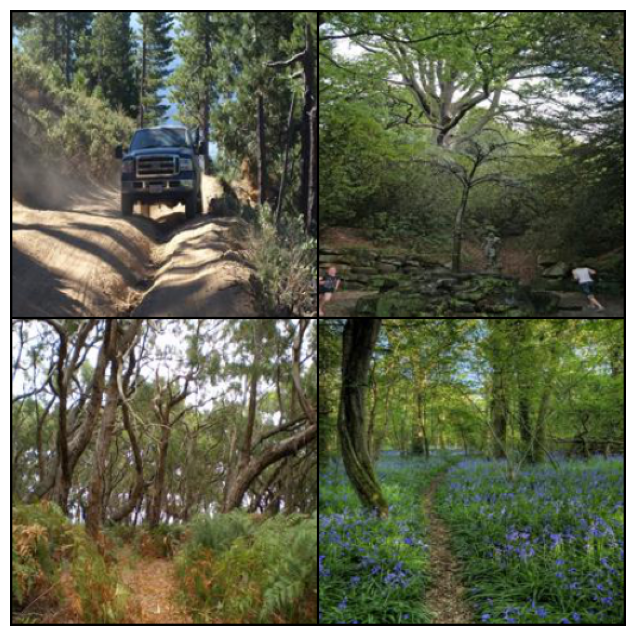

In [20]:
def denormalize(images: torch.Tensor) -> torch.Tensor:
    return (images * 0.5 + 0.5).clamp(0, 1)


batch_images, batch_labels = next(iter(train_loader))
grid = utils.make_grid(denormalize(batch_images[:4]), nrow=2)

plt.figure(figsize=(8, 8))
plt.axis("off")
plt.imshow(grid.permute(1, 2, 0))
plt.show()


## Cleaner GAN Architecture

The previous run showed strong checkerboard artifacts, which often come from stacked transpose convolutions. This version uses nearest-neighbor upsampling followed by regular convolutions in the generator to reduce that artifact pattern.


In [21]:
class UpBlock(nn.Module):
    def __init__(self, in_channels: int, out_channels: int) -> None:
        super().__init__()
        self.block = nn.Sequential(
            nn.Upsample(scale_factor=2, mode="nearest"),
            nn.Conv2d(in_channels, out_channels, kernel_size=3, stride=1, padding=1, bias=False),
            nn.BatchNorm2d(out_channels),
            nn.ReLU(True),
        )

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        return self.block(x)


class Generator(nn.Module):
    def __init__(self, latent_dim: int, ngf: int, num_channels: int) -> None:
        super().__init__()
        self.project = nn.Sequential(
            nn.ConvTranspose2d(latent_dim, ngf * 16, 4, 1, 0, bias=False),
            nn.BatchNorm2d(ngf * 16),
            nn.ReLU(True),
        )
        self.upsampler = nn.Sequential(
            UpBlock(ngf * 16, ngf * 8),
            UpBlock(ngf * 8, ngf * 4),
            UpBlock(ngf * 4, ngf * 2),
            UpBlock(ngf * 2, ngf),
            UpBlock(ngf, ngf // 2),
            UpBlock(ngf // 2, ngf // 4),
        )
        self.to_rgb = nn.Sequential(
            nn.Conv2d(ngf // 4, num_channels, kernel_size=3, stride=1, padding=1),
            nn.Tanh(),
        )

    def forward(self, noise: torch.Tensor) -> torch.Tensor:
        x = self.project(noise)
        x = self.upsampler(x)
        return self.to_rgb(x)


class Discriminator(nn.Module):
    def __init__(self, ndf: int, num_channels: int) -> None:
        super().__init__()
        self.net = nn.Sequential(
            nn.Conv2d(num_channels, ndf, 4, 2, 1, bias=False),
            nn.LeakyReLU(0.2, inplace=True),
            nn.Conv2d(ndf, ndf * 2, 4, 2, 1, bias=False),
            nn.BatchNorm2d(ndf * 2),
            nn.LeakyReLU(0.2, inplace=True),
            nn.Conv2d(ndf * 2, ndf * 4, 4, 2, 1, bias=False),
            nn.BatchNorm2d(ndf * 4),
            nn.LeakyReLU(0.2, inplace=True),
            nn.Conv2d(ndf * 4, ndf * 8, 4, 2, 1, bias=False),
            nn.BatchNorm2d(ndf * 8),
            nn.LeakyReLU(0.2, inplace=True),
            nn.Conv2d(ndf * 8, ndf * 16, 4, 2, 1, bias=False),
            nn.BatchNorm2d(ndf * 16),
            nn.LeakyReLU(0.2, inplace=True),
            nn.Conv2d(ndf * 16, ndf * 32, 4, 2, 1, bias=False),
            nn.BatchNorm2d(ndf * 32),
            nn.LeakyReLU(0.2, inplace=True),
            nn.Conv2d(ndf * 32, 1, 4, 1, 0, bias=False),
        )

    def forward(self, images: torch.Tensor) -> torch.Tensor:
        return self.net(images).view(-1)


def weights_init(module: nn.Module) -> None:
    classname = module.__class__.__name__
    if "Conv" in classname:
        nn.init.normal_(module.weight.data, 0.0, 0.02)
    elif "BatchNorm" in classname:
        nn.init.normal_(module.weight.data, 1.0, 0.02)
        nn.init.constant_(module.bias.data, 0)


In [22]:
generator = Generator(config.latent_dim, config.ngf, config.num_channels).to(device)
discriminator = Discriminator(config.ndf, config.num_channels).to(device)

generator.apply(weights_init)
discriminator.apply(weights_init)

criterion = nn.BCEWithLogitsLoss()
optimizer_g = optim.Adam(generator.parameters(), lr=config.learning_rate_g, betas=(config.beta1, 0.999))
optimizer_d = optim.Adam(discriminator.parameters(), lr=config.learning_rate_d, betas=(config.beta1, 0.999))

fixed_noise = torch.randn(4, config.latent_dim, 1, 1, device=device)

print("Generator params:", sum(p.numel() for p in generator.parameters()))
print("Discriminator params:", sum(p.numel() for p in discriminator.parameters()))


Generator params: 10488723
Discriminator params: 44739328


In [23]:
def denormalize(images: torch.Tensor) -> torch.Tensor:
    return (images * 0.5 + 0.5).clamp(0, 1)


def save_checkpoint(epoch: int) -> None:
    torch.save(
        {
            "epoch": epoch,
            "config": asdict(config),
            "generator_state_dict": generator.state_dict(),
            "discriminator_state_dict": discriminator.state_dict(),
            "optimizer_g_state_dict": optimizer_g.state_dict(),
            "optimizer_d_state_dict": optimizer_d.state_dict(),
        },
        config.checkpoint_dir / f"background_256_epoch_{epoch:03d}.pt",
    )


def save_sample_grid(epoch: int) -> Path:
    generator.eval()
    with torch.no_grad():
        samples = generator(fixed_noise).cpu()
    generator.train()

    sample_path = config.sample_dir / f"background_256_epoch_{epoch:03d}.png"
    utils.save_image(denormalize(samples), sample_path, nrow=2)
    return sample_path


def show_sample_grid(sample_path: Path, title: str | None = None) -> None:
    image = plt.imread(sample_path)
    plt.figure(figsize=(8, 8))
    if title is not None:
        plt.title(title)
    plt.axis("off")
    plt.imshow(image)
    plt.show()


Epoch 1/100:   0%|          | 0/1250 [00:00<?, ?it/s]

Epoch 001 | steps: 80 | D: 5.6075 | G: 40.8835 | time: 35.7s
Saved samples to /Users/shrimayee/sdeshpan/ADL/DreamTales/DreamVision 2.0/outputs/backgrounds_256/samples/background_256_epoch_001.png


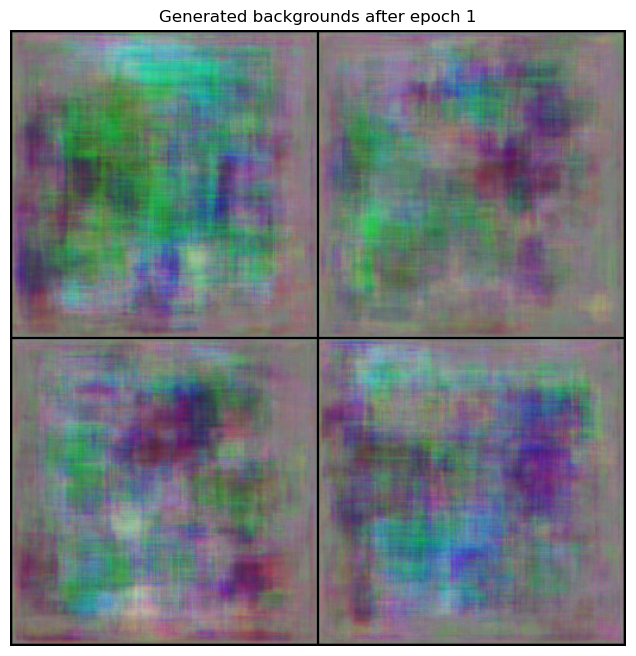

Epoch 2/100:   0%|          | 0/1250 [00:00<?, ?it/s]

Epoch 002 | steps: 80 | D: 5.9492 | G: 25.6104 | time: 36.5s
Saved samples to /Users/shrimayee/sdeshpan/ADL/DreamTales/DreamVision 2.0/outputs/backgrounds_256/samples/background_256_epoch_002.png


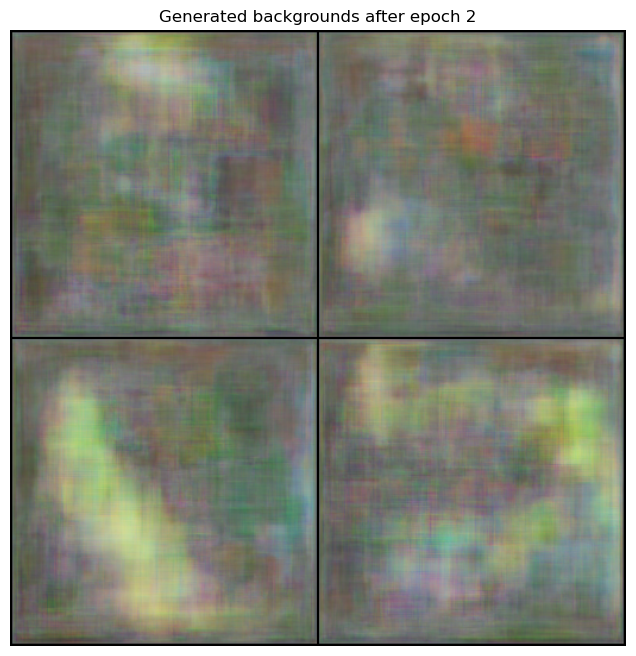

Epoch 3/100:   0%|          | 0/1250 [00:00<?, ?it/s]

In [ ]:
history = []

for epoch in range(1, config.num_epochs + 1):
    start_time = time.time()
    g_running = 0.0
    d_running = 0.0
    steps_completed = 0

    progress = tqdm(train_loader, desc=f"Epoch {epoch}/{config.num_epochs}")
    for step_idx, (real_images, _) in enumerate(progress, start=1):
        if config.max_steps_per_epoch is not None and step_idx > config.max_steps_per_epoch:
            break

        real_images = real_images.to(device, non_blocking=True)
        batch_size = real_images.size(0)

        real_targets = torch.ones(batch_size, device=device)
        fake_targets = torch.zeros(batch_size, device=device)

        discriminator.zero_grad(set_to_none=True)

        real_output = discriminator(real_images)
        d_loss_real = criterion(real_output, real_targets)

        noise = torch.randn(batch_size, config.latent_dim, 1, 1, device=device)
        fake_images = generator(noise)
        fake_output = discriminator(fake_images.detach())
        d_loss_fake = criterion(fake_output, fake_targets)

        d_loss = d_loss_real + d_loss_fake
        d_loss.backward()
        optimizer_d.step()

        generator.zero_grad(set_to_none=True)

        gen_output = discriminator(fake_images)
        g_loss = criterion(gen_output, real_targets)
        g_loss.backward()
        optimizer_g.step()

        g_running += g_loss.item()
        d_running += d_loss.item()
        steps_completed += 1
        progress.set_postfix(d_loss=f"{d_loss.item():.4f}", g_loss=f"{g_loss.item():.4f}")

    avg_g = g_running / max(steps_completed, 1)
    avg_d = d_running / max(steps_completed, 1)
    elapsed = time.time() - start_time

    history.append({
        "epoch": epoch,
        "g_loss": avg_g,
        "d_loss": avg_d,
        "epoch_time_sec": elapsed,
        "steps_completed": steps_completed,
    })

    print(f"Epoch {epoch:03d} | steps: {steps_completed} | D: {avg_d:.4f} | G: {avg_g:.4f} | time: {elapsed:.1f}s")

    if epoch % config.sample_interval == 0:
        sample_path = save_sample_grid(epoch)
        print(f"Saved samples to {sample_path}")
        show_sample_grid(sample_path, title=f"Generated backgrounds after epoch {epoch}")

    if epoch % config.checkpoint_interval == 0:
        save_checkpoint(epoch)
        print(f"Saved checkpoint for epoch {epoch}")


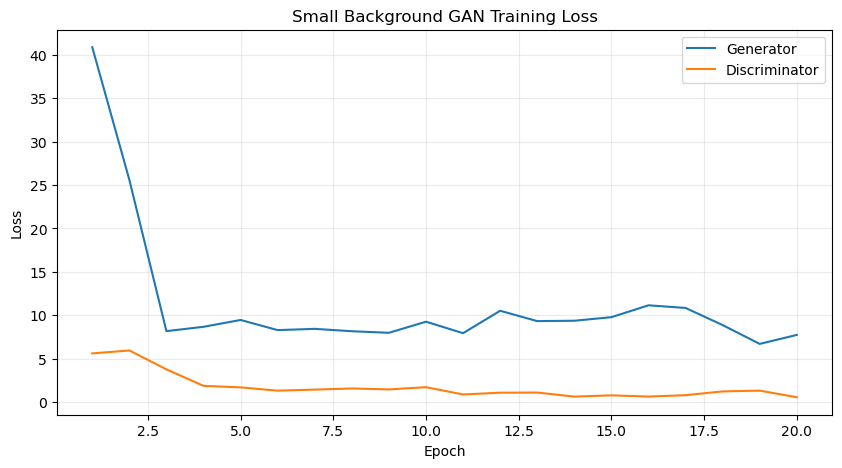

In [16]:
epochs = [row["epoch"] for row in history]
g_losses = [row["g_loss"] for row in history]
d_losses = [row["d_loss"] for row in history]

plt.figure(figsize=(10, 5))
plt.plot(epochs, g_losses, label="Generator")
plt.plot(epochs, d_losses, label="Discriminator")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Small Background GAN Training Loss")
plt.legend()
plt.grid(True, alpha=0.25)
plt.show()

if history:
    last_epoch = history[-1]["epoch"]
    last_sample = config.sample_dir / f"background_small_epoch_{last_epoch:03d}.png"
    if last_sample.exists():
        show_sample_grid(last_sample, title=f"Latest generated backgrounds: epoch {last_epoch}")


## Next Steps

After this local `forest_path` run, the sensible next moves are:
- train longer if structure is improving
- raise `max_steps_per_epoch` if your Mac still feels comfortable
- add `park` only after `forest_path` alone looks clean
- keep HiPerGator as the scale-up path once the uploads finish
